## Imports

In [70]:
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display
from gerrychain import Graph

## Init Map

In [71]:
vtds = gpd.read_file("data/mo_2020_vtd/mo_2020.shp")
cois = gpd.read_file("data/mo_2021_coi/MO_20210924_phase_C_summary.shp")

# align coords on both maps
if cois.crs != vtds.crs:
    vtds = vtds.to_crs(cois.crs)

## need total pop column, add up presidential votes to get
pres_cols = ['G20PRERTRU', 'G20PREDBID', 'G20PRELJOR', 'G20PREGHAW', 'G20PRECBLA']
vtds['TOTPOP'] = vtds[pres_cols].sum(axis=1)

## now need coi fractions per vtd
# total vtd area
vtds['vtd_area'] = vtds.geometry.area

# what fraction of community resides here? coi area / total area
overlaps = gpd.overlay(vtds, cois, how='intersection')
overlaps['coi_fraction'] = overlaps.geometry.area / overlaps['vtd_area']

#display(overlaps[['NAME', 'cluster', 'coi_fraction', 'TOTPOP']].head(10))

In [72]:
# drop tiny overlaps
clean_overlaps = overlaps[overlaps['coi_fraction'] > 0.01].copy()

# figure out num people from overlaps pct
clean_overlaps['coi_pop'] = clean_overlaps['TOTPOP'] * clean_overlaps['coi_fraction']

coi_dict = {}
for index, row in clean_overlaps.iterrows():
    precinct_name = row['NAME']
    cluster_id = row['cluster']
    population_chunk = row['coi_pop']
    
    if precinct_name not in coi_dict:
        coi_dict[precinct_name] = {}
        
    coi_dict[precinct_name][cluster_id] = population_chunk

vtds['COI_POPS'] = [coi_dict.get(name, {}) for name in vtds['NAME']]

vtds.geometry = vtds.geometry.buffer(0)
g = Graph.from_geodataframe(vtds)


/Users/jevonlipsey/miniconda3/envs/mcure/lib/python3.12/site-packages/gerrychain/graph/adjacency.py:112: UserWarning: Found overlaps among the given polygons. Indices of overlaps: {(3097, 3358), (3691, 3692), (521, 1469), (2399, 3085), (1257, 3721), (2210, 2593), (2818, 2823), (3695, 3697), (3696, 3697), (1392, 1773), (526, 1773), (3709, 3717), (3721, 3722), (1257, 3722), (1689, 1782), (3672, 3673), (2593, 3119), (674, 1773), (3693, 3694), (1617, 1843)}
  warnings.warn(


In [73]:
#print(vtds.columns)
#(vtds.head(1))
display(vtds[['NAME', 'TOTPOP', 'COI_POPS']].head(10))

,NAME,TOTPOP,COI_POPS
0,Commerce,376,{'C29': 375.99348264324686}
1,West Finley,2221,"{'C27-1': 887.9613364658306, 'C27-2': 1148.053..."
2,Huntsville,687,{'C20': 687.0000000000003}
3,Barry East,2656,"{'C14': 2656.0, 'C13': 2656.0}"
4,California 3,871,{'C20': 871.0000000000003}
5,Marquand,498,{'C29': 324.5919238633417}
6,Wellsville,744,{'C22': 744.0000000000003}
7,Foristell,2041,"{'C1': 2040.9999999999977, 'C7': 2040.99999999..."
8,Warrenton 3,1081,"{'C1': 1081.0000000000016, 'C7': 1081.00000000..."
9,KC 21 Gallatin 4,1322,"{'C14': 1322.0, 'C13': 1322.0}"


## Plotting

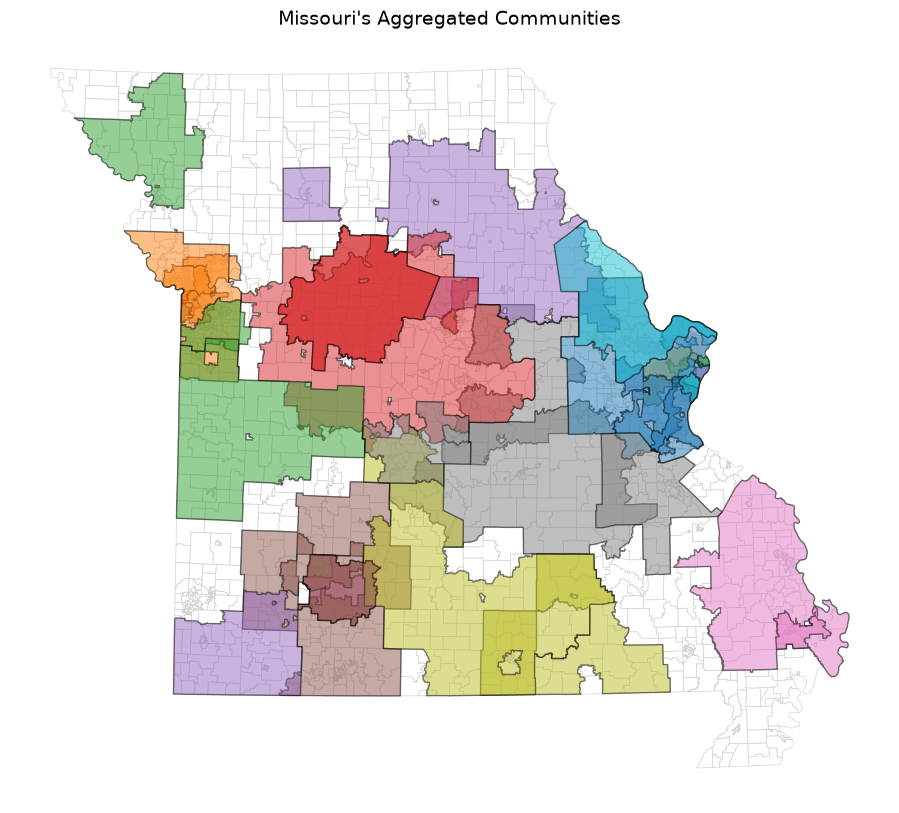

In [74]:
fig, ax = plt.subplots(figsize=(12, 10))

vtds.plot(ax=ax, color="white", edgecolor="lightgray", linewidth=0.5)
cois.plot(ax=ax, column="cluster", alpha=0.5, edgecolor="black")

ax.set_title("Missouri's Aggregated Communities", fontsize=14)
ax.axis("off")
plt.show()